In [2]:
%autoreload 2

In [1]:
%reload_ext autoreload
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib import  rcParams
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
path = (r'C:/Data/Imaging\260425_overlap//fish5//')
rcParams['font.size'] = 12

In [2]:
fish = Gafftopsail(path, filelist = ['stimulus', 'imaging', 'alignment'], sequence = 5)
fish.stimulus_df.stim_name = [str(s) for s in fish.stimulus_df.stim_name]

low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed


__EACH STIM__

In [3]:
#axis 0: trial; axis 1: neuron; axis 2: frame
#from stationary start to duration + 20
f_pertrial_dict = barcode.get_pertrial_f(fish)

getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s


__barcoding__

In [5]:
barred_dotneurons = barcode.select_dotbarcode(fish, f_pertrial_dict, baseline_s = 7, response_s =10, perc_trial_threshold = 1)

selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2


In [6]:
fish.stimulus_df.loc[:, "somehuntingresponse"] = fish.stimulus_df.hunting_eye | fish.stimulus_df.hunting_tail

__Look at response during overlap__

In [3]:
def get_f_efference(fish, barred_dotneurons):
    """Get the avg trace of a population of cells"""
    #look at vis responsive cells
    region_list = [['prosencephalon_(forebrain)', 'mesencephalon_(midbrain)'], 'rhombencephalon_(hindbrain)', 'tectum', 'pretectum']

    #get traces
    f_dict = {'forebrain':{}, 'hindbrain':{}, 'tectum': {}, 'pretectum': {}}

    fig, ax = plt.subplots(len(barred_dotneurons), 1 + 2 * len(region_list), figsize = (20, 10))
    #each direction: line vs dot line
    for s, stim in enumerate(barred_dotneurons):
        stim_n = set(barred_dotneurons[stim])
        ax_imshow = ax[s, 0]
        ax_imshow.imshow(fish.img_dict[2], origin = 'lower')
        ax_imshow.set_axis_off()
        for r, (region, region_c) in enumerate(zip(region_list, ['white', 'grey', 'yellow','green'])):
            ax_line = ax[s, r * 2 + 1]
            ax_heat = ax[s, r * 2 + 2]
            f_df = []
            if type(region) == list:
                region_n = set(fish.apos_all.index[fish.apos_all['regions'].apply(lambda x: any(ri in x for ri in region))])#set(fish.apos_all.index)#
            else:
                region_n = set(fish.apos_all.index[fish.apos_all['regions'].apply(lambda x: region in x)])
            region_n = list(region_n & stim_n)

            ax_imshow.scatter(fish.pos_all.loc[region_n, 'xpos'], fish.pos_all.loc[region_n, 'ypos'], marker = ',', s = 1, color = region_c)
            for g, (grating, color) in enumerate(zip([None, 'forward', 'left', 'right', 'backward'], [utils.pink, utils.omr_colors['forward'], utils.omr_colors['left'], utils.omr_colors['right'], utils.omr_colors['backward']])):
                if grating == None:
                    linestyle = ':'
                    real_stim = stim
                else:
                    linestyle = '-'
                    real_stim =  str([stim, grating])
                #find trials that have motor movements
                trial_df = fish.stimulus_df[fish.stimulus_df.stim_name == real_stim].reset_index(drop = True)
                motortrials = list(trial_df[trial_df.somehuntingresponse].index)
                nonmotortrials = list(trial_df[~trial_df.somehuntingresponse].index)
                for m, (triallist, motor) in enumerate(zip([motortrials, nonmotortrials], [True, False])):
                    #get fluorscnece
                    f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
                    f_mean = f_acrosstrial.mean(axis = 0)
                    f_sem = f_acrosstrial.std(axis=0) / np.sqrt(f_acrosstrial.shape[0])
                    df = pd.DataFrame(f_acrosstrial)
                    if len(df) > 0:
                        df.loc[:, 'barred'] = stim
                        df.loc[:, 'stim'] = real_stim
                        df.loc[:, 'gratingresponse'] = motor
                    f_df.append(df)
                    #start plotting
                    if not motor: actualcolor = 'grey'
                    else: actualcolor = color
                    ax_line.plot(f_mean, c=actualcolor, linestyle = linestyle)#color: grating, linestyle: dot, alpha: motor
                    ax_line.fill_between(np.arange(len(f_mean)),f_mean - f_sem, f_mean + f_sem,color=actualcolor,alpha=0.1, linewidth = 0)
                    ax_line.set_ylim([0.1, 0.6])
                    ax_heat.imshow(f_acrosstrial, aspect='auto',extent=[0, len(f_mean), g * 2 + m, g * 2 + m + 1],cmap='viridis', vmin = 0.2, vmax = 0.6)
                    ax_heat.axhline(g* 2 + m, linestyle='--', color='white')
            ax_heat.set_ylim([0, g * 2 + m + 1])
            if s == 0:
                f_dict[list(f_dict.keys())[r]] = pd.concat(f_df, axis = 0, ignore_index = True)
            else:
                f_dict[list(f_dict.keys())[r]] = pd.concat([f_dict[list(f_dict.keys())[r]], pd.concat(f_df, axis = 0, ignore_index = True)], axis = 0, ignore_index = True)
    return f_dict

C:\Users\Zichen\AppData\Local\Temp\ipykernel_70728\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_70728\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_70728\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_70728\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_70728\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppD

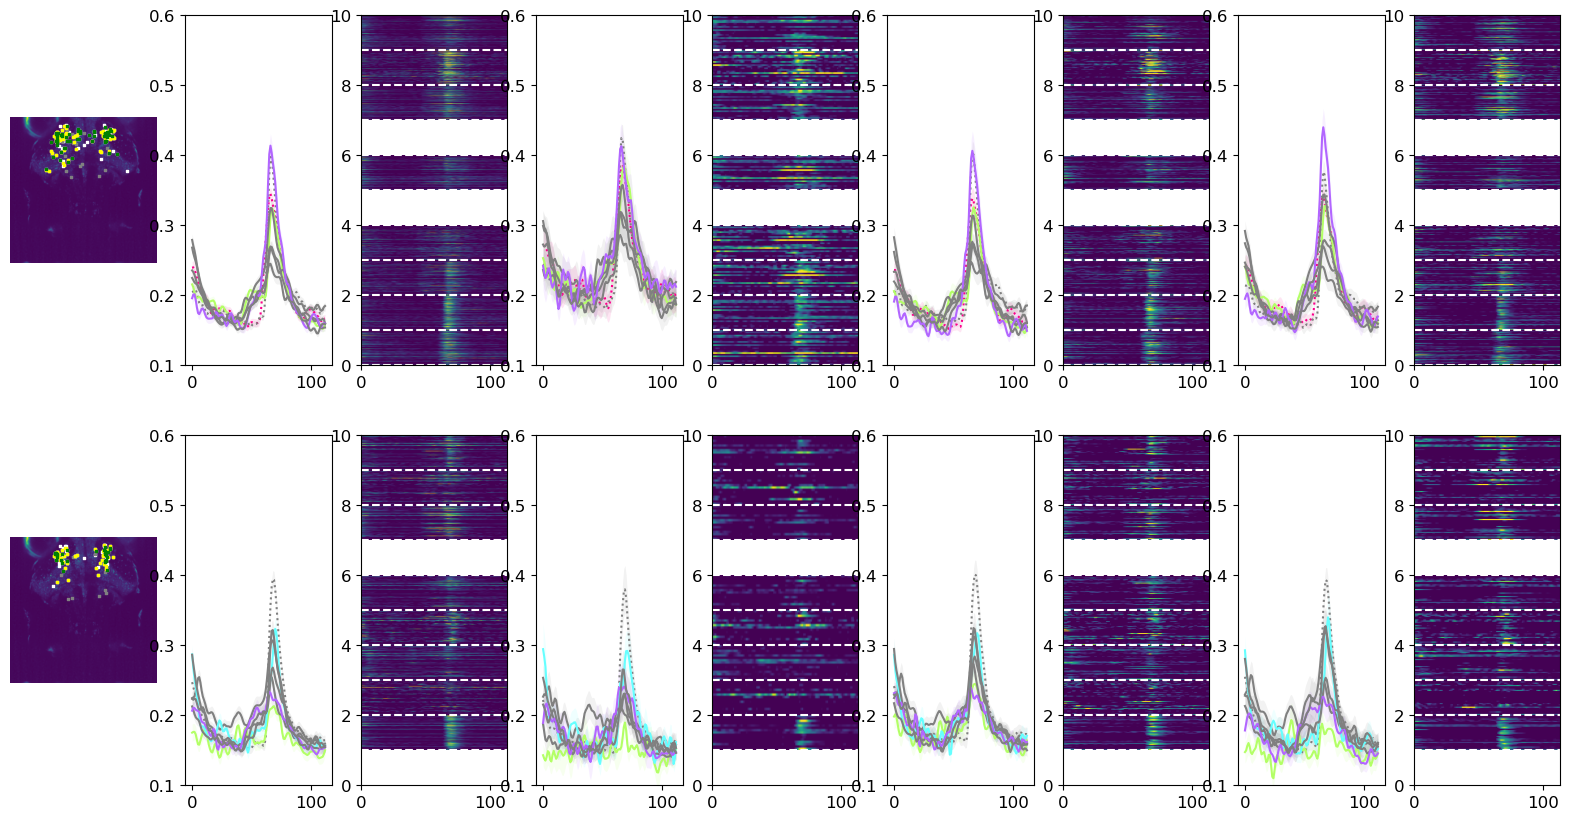

In [13]:

f_dict = get_f_efference(fish, barred_dotneurons)
plt.show()
plt.close()

In [5]:
#combine across fish
paths =[
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
 r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",]
for path in paths:
    fish = Gafftopsail(path + '//', filelist=['stimulus', 'imaging', 'alignment'], sequence=5)
    fish.stimulus_df.stim_name = [str(s) for s in fish.stimulus_df.stim_name]
    fish.stimulus_df.loc[:, "somehuntingresponse"] = fish.stimulus_df.hunting_eye | fish.stimulus_df.hunting_tail

    #axis 0: trial; axis 1: neuron; axis 2: frame
    #from stationary start to duration + 20
    f_pertrial_dict = barcode.get_pertrial_f(fish)
    barred_dotneurons = barcode.select_dotbarcode(fish, f_pertrial_dict, baseline_s=7, response_s=10,
                                                  perc_trial_threshold=1)
    f_dict  = get_f_efference(fish, barred_dotneurons)
    for region in ['forebrain', 'hindbrain', 'tectum', 'pretectum']:
        df = f_dict[region]
        df.to_csv(fish.path + f"//analyze_results//dotefference_{region}neurons.csv")

    plt.close()

low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2


C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\L

low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2


C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\L

low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2


...

C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\L

low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2


C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\L

low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2


C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
C:\Users\Zichen\AppData\Local\Temp\ipykernel_8140\3343140824.py:40: RuntimeWarning: Mean of empty slice
  f_acrosstrial = np.nanmean(f_pertrial_dict[real_stim][triallist][:, region_n], axis = 0)
